In [16]:
import sys 
sys.path.append("../../Ray Tracing in One Weekend/")

In [35]:
from util.ray import Ray
from util.vec3 import (
    Vec3,
    unit_vector,
    random_on_hemisphere
)
from util.hit_record import HitRecord
from util.interval import Interval
from util.utility import INFINITY
from tqdm import tqdm
from util.image_viewer import image_viewer



class Camera:

    def __init__(self):
        self.aspect_ratio = 16 / 9
        self.image_width = 400
        self.samples_per_pixel = 100
        self.max_depth = 10

    # -----------------------------------
    # Setup
    # -----------------------------------
    def initialize(self):

        self.image_height = int(
            self.image_width / self.aspect_ratio
        )

        if self.image_height < 1:
            self.image_height = 1

        self.pixel_samples_scale = (
            1.0 / self.samples_per_pixel
        )

        self.center = Vec3(0, 0, 0)

        focal_length = 1.0
        viewport_height = 2.0
        viewport_width = (
            viewport_height *
            (self.image_width / self.image_height)
        )

        viewport_u = Vec3(viewport_width, 0, 0)
        viewport_v = Vec3(0, -viewport_height, 0)

        self.pixel_delta_u = (
            viewport_u / self.image_width
        )

        self.pixel_delta_v = (
            viewport_v / self.image_height
        )

        viewport_upper_left = (
            self.center
            - Vec3(0, 0, focal_length)
            - viewport_u / 2
            - viewport_v / 2
        )

        self.pixel00_loc = (
            viewport_upper_left
            + 0.5 * (
                self.pixel_delta_u +
                self.pixel_delta_v
            )
        )

    # -----------------------------------
    # Random subpixel
    # -----------------------------------
    def sample_square(self):
        import random

        return Vec3(
            random.random() - 0.5,
            random.random() - 0.5,
            0
        )

    # -----------------------------------
    # Build ray
    # -----------------------------------
    def get_ray(self, i, j):

        offset = self.sample_square()

        pixel_sample = (
            self.pixel00_loc
            + (i + offset.x) * self.pixel_delta_u
            + (j + offset.y) * self.pixel_delta_v
        )

        ray_direction = pixel_sample - self.center

        return Ray(self.center, ray_direction)

    # -----------------------------------
    # Recursive diffuse light
    # -----------------------------------
    def ray_color(self, r, world, depth):

        if depth <= 0:
            return Vec3(0, 0, 0)

        rec = HitRecord()

        if world.hit(
            r,
            Interval(0.001, INFINITY),
            rec
        ):
            direction = random_on_hemisphere(
                rec.normal
            )

            return 0.5 * self.ray_color(
                Ray(rec.p, direction),
                world,
                depth - 1
            )

        unit_dir = unit_vector(r.direction())

        t = 0.5 * (unit_dir.y + 1.0)

        white = Vec3(1, 1, 1)
        blue = Vec3(0.5, 0.7, 1.0)

        return (
            (1.0 - t) * white +
            t * blue
        )

    # -----------------------------------
    # Render
    # -----------------------------------
    def render(self, world):

        self.initialize()

        with open("output.ppm", "w") as f:

            f.write(
                f"P3\n{self.image_width} "
                f"{self.image_height}\n255\n"
            )

            for j in tqdm(range(self.image_height)):

                for i in range(self.image_width):

                    pixel_color = Vec3(0, 0, 0)

                    for _ in range(
                        self.samples_per_pixel
                    ):

                        r = self.get_ray(i, j)

                        pixel_color += self.ray_color(r, world, self.max_depth)

                    pixel_color *= (self.pixel_samples_scale)

                    ir = int(255.999 * pixel_color.x)
                    ig = int(255.999 * pixel_color.y)
                    ib = int(255.999 * pixel_color.z)

                    f.write(
                        f"{ir} {ig} {ib}\n"
                    )

    def show(self):
        """
        Display output image
        """
        return image_viewer("output.ppm")                


In [36]:
from util.sphere import Sphere
#from util.camera_antialias import Camera
from util.hittable_list import HittableList
from util.vec3 import Vec3

world = HittableList()

world.add(Sphere(Vec3(0, 0, -1), 0.5))
world.add(Sphere(Vec3(0, -100.5, -1), 100))

cam = Camera()

cam.aspect_ratio = 16 / 9
cam.image_width = 1920//2
cam.samples_per_pixel = 1
cam.max_depth = 100

cam.render(world)

100%|██████████| 540/540 [00:14<00:00, 37.13it/s]


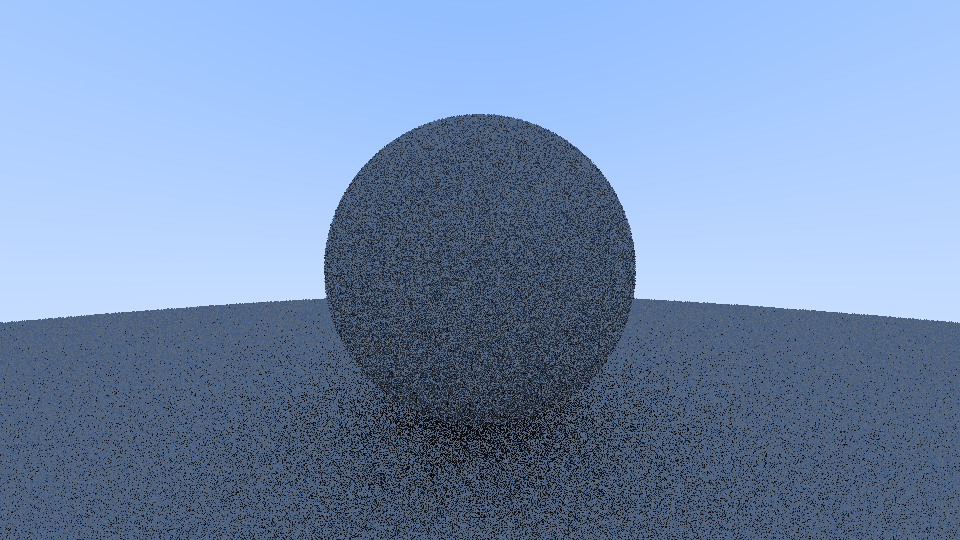

In [37]:
cam.show()

Good — you’re now entering the **first real light transport step** of the ray tracer: **diffuse scattering**.

Right now your Python code only shows:

* surface normals → fake coloring
* background gradient

Now we replace that with:

> **random bouncing rays**

This creates soft matte shading.

---

# 1. What is diffuse?

A diffuse surface scatters light in random directions.

Examples:

* chalk
* paper
* wall
* clay

Unlike mirrors:

Mirror:

$$
R = D - 2(D\cdot N)N
$$

Diffuse:

$$
R = \text{random direction above surface}
$$

So:

| Material | Behavior            |
| -------- | ------------------- |
| Metal    | one exact bounce    |
| Diffuse  | many random bounces |

---

# 2. Goal

Old:

```python
return 0.5 * (rec.normal + Vec3(1,1,1))
```

This only visualizes normals.

New:

```python
direction = random_on_hemisphere(rec.normal)
return 0.5 * self.ray_color(Ray(rec.p, direction), world)
```

Now the ray keeps bouncing.

---

# 3. Required vector functions

Add these to `vec3.py`

---

# Random vector generation

Purpose:

Generate random vector:

$$
(x,y,z)
$$

where:

$$
x,y,z \in [a,b]
$$

---

| Function         | Purpose                       |
| ---------------- | ----------------------------- |
| `random()`       | random vector in $[0,1]$      |
| `random_range()` | random vector in custom range |

```python
import random
import math


class Vec3:
    ...
    
    @staticmethod
    def random():
        """
        Random vector in [0,1]
        """
        return Vec3(
            random.random(),
            random.random(),
            random.random()
        )

    @staticmethod
    def random_range(min_v, max_v):
        """
        Random vector in [min,max]
        """
        return Vec3(
            random.uniform(min_v, max_v),
            random.uniform(min_v, max_v),
            random.uniform(min_v, max_v)
        )
```

---

# 4. Random unit vector

Purpose:

Generate:

$$
|v| = 1
$$

using rejection sampling.

---

## Formula

Generate:

$$
p=(x,y,z)
$$

inside cube:

$$
[-1,1]^3
$$

Accept only if:

$$
x^2+y^2+z^2 \le 1
$$

Then normalize:

$$
\hat p = \frac{p}{|p|}
$$

---

## Why?

This gives random direction.

---

| Step                  | Purpose                |
| --------------------- | ---------------------- |
| generate point        | random candidate       |
| reject outside sphere | keep valid             |
| normalize             | move to sphere surface |

Add:

```python
def random_unit_vector():
    """
    Generate random unit vector
    """

    while True:

        # random point inside cube
        p = Vec3.random_range(-1, 1)

        # squared length
        lensq = p.length_squared()

        # reject bad points
        if 1e-160 < lensq <= 1:
            return p / math.sqrt(lensq)
```

---

# 5. Hemisphere scattering

Purpose:

Make sure bounce goes outward.

Surface normal tells which half-space is valid.

---

## Dot product test

If:

$$
v \cdot n > 0
$$

same hemisphere.

If:

$$
v \cdot n < 0
$$

wrong hemisphere.

Flip:

$$
-v
$$

---

Add:

```python
def random_on_hemisphere(normal):
    """
    Return random vector on same hemisphere
    as normal
    """

    on_unit_sphere = random_unit_vector()

    if dot(on_unit_sphere, normal) > 0.0:
        return on_unit_sphere
    else:
        return -on_unit_sphere
```

---

# 6. Update ray_color()

Old:

```python
return 0.5 * (rec.normal + Vec3(1,1,1))
```

Replace with:

```python
def ray_color(self, r, world, depth=10):
    """
    Recursive diffuse ray tracing
    """

    if depth <= 0:
        return Vec3(0, 0, 0)

    rec = HitRecord()

    if world.hit(r, Interval(0.001, INFINITY), rec):

        # random bounce direction
        direction = random_on_hemisphere(rec.normal)

        # recursive bounce
        return 0.5 * self.ray_color(
            Ray(rec.p, direction),
            world,
            depth - 1
        )

    # sky gradient
    unit_dir = unit_vector(r.direction())

    t = 0.5 * (unit_dir.y + 1.0)

    white = Vec3(1, 1, 1)
    blue = Vec3(0.5, 0.7, 1.0)

    return white * (1 - t) + blue * t
```

---

# 7. Why recursive?

Because light bounces many times.

Mathematically:

$$
L(p)=aL(p')
$$

where:

* $L(p)$ = light at current point
* $a=0.5$ attenuation
* $p'$ = next bounce point

Expanded:

$$
L = 0.5(0.5(0.5(...)))
$$

This creates global illumination.

---

# 8. Why depth?

Without limit:

$$
L \to \infty
$$

recursion never stops.

So:

$$
depth = depth - 1
$$

When:

$$
depth=0
$$

stop.

---

| Parameter | Meaning        |
| --------- | -------------- |
| depth=10  | max 10 bounces |
| depth=50  | smoother       |
| depth=100 | expensive      |

---

# Full pipeline

```text
Ray hits surface
        ↓
Get normal
        ↓
Generate random unit vector
        ↓
Check hemisphere
        ↓
Bounce ray
        ↓
Reduce energy by 0.5
        ↓
Repeat recursively
        ↓
Hit sky
        ↓
Return color
```

---

This is the first true Monte Carlo ray tracer step:

$$
L_o = \int_{\Omega} f_r L_i (\omega_i)(n\cdot \omega_i)d\omega_i
$$

You are approximating it by random sampling.


# Camera


Below is the **full proper Python version** for the diffuse material step (equivalent to *Ray Tracing in One Weekend* Chapter: Simple Diffuse Material).

I’ll keep it modular so it fits your current project.

---

# 1. `vec3.py`

Purpose:

Vector math + random diffuse sampling.

---

## Core formulas

Length:

$$
|v| = \sqrt{x^2+y^2+z^2}
$$

Unit vector:

$$
\hat v = \frac{v}{|v|}
$$

Dot product:

$$
a \cdot b = axbx + ayby + azbz
$$

Hemisphere check:

$$
v \cdot n > 0
$$

---

| Function                 | Purpose                |
| ------------------------ | ---------------------- |
| `random_range()`         | random vector in range |
| `random_unit_vector()`   | random direction       |
| `random_on_hemisphere()` | outward bounce         |

```python
import math
import random


class Vec3:
    def __init__(self, x=0, y=0, z=0):
        self.e = [x, y, z]

    # --------------------------
    # Properties
    # --------------------------
    @property
    def x(self):
        return self.e[0]

    @property
    def y(self):
        return self.e[1]

    @property
    def z(self):
        return self.e[2]

    # --------------------------
    # Operators
    # --------------------------
    def __neg__(self):
        return Vec3(-self.x, -self.y, -self.z)

    def __add__(self, other):
        return Vec3(
            self.x + other.x,
            self.y + other.y,
            self.z + other.z
        )

    def __sub__(self, other):
        return Vec3(
            self.x - other.x,
            self.y - other.y,
            self.z - other.z
        )

    def __mul__(self, t):
        if isinstance(t, Vec3):
            return Vec3(
                self.x * t.x,
                self.y * t.y,
                self.z * t.z
            )

        return Vec3(
            self.x * t,
            self.y * t,
            self.z * t
        )

    def __rmul__(self, t):
        return self.__mul__(t)

    def __truediv__(self, t):
        return self * (1 / t)

    def __str__(self):
        return f"{self.x} {self.y} {self.z}"

    # --------------------------
    # Length
    # --------------------------
    def length_squared(self):
        return (
            self.x * self.x +
            self.y * self.y +
            self.z * self.z
        )

    def length(self):
        return math.sqrt(self.length_squared())

    # --------------------------
    # Random vectors
    # --------------------------
    @staticmethod
    def random():
        return Vec3(
            random.random(),
            random.random(),
            random.random()
        )

    @staticmethod
    def random_range(min_v, max_v):
        return Vec3(
            random.uniform(min_v, max_v),
            random.uniform(min_v, max_v),
            random.uniform(min_v, max_v)
        )


# --------------------------
# Utility functions
# --------------------------
def dot(u, v):
    return (
        u.x * v.x +
        u.y * v.y +
        u.z * v.z
    )


def cross(u, v):
    return Vec3(
        u.y * v.z - u.z * v.y,
        u.z * v.x - u.x * v.z,
        u.x * v.y - u.y * v.x
    )


def unit_vector(v):
    return v / v.length()


# --------------------------
# Diffuse helpers
# --------------------------
def random_unit_vector():
    """
    Rejection sampling inside unit sphere
    """

    while True:
        p = Vec3.random_range(-1, 1)

        lensq = p.length_squared()

        if 1e-160 < lensq <= 1:
            return p / math.sqrt(lensq)


def random_on_hemisphere(normal):
    """
    Keep ray in outward hemisphere
    """

    on_unit_sphere = random_unit_vector()

    if dot(on_unit_sphere, normal) > 0.0:
        return on_unit_sphere

    return -on_unit_sphere


Point3 = Vec3
Color = Vec3
```

---

# 2. `ray.py`

Formula:

$$
P(t)=A+tB
$$

| Symbol | Meaning   |
| ------ | --------- |
| $A$    | origin    |
| $B$    | direction |

```python
class Ray:
    def __init__(self, origin, direction):
        self.orig = origin
        self.dir = direction

    def origin(self):
        return self.orig

    def direction(self):
        return self.dir

    def at(self, t):
        return self.orig + t * self.dir
```

---

# 3. `camera.py`

Purpose:

Diffuse recursive ray tracing.

Main recursion:

$$
L = 0.5L'
$$

---

```python
from util.ray import Ray
from util.vec3 import (
    Vec3,
    unit_vector,
    random_on_hemisphere
)
from util.hit_record import HitRecord
from util.interval import Interval
from util.utility import INFINITY
from tqdm import tqdm


class Camera:

    def __init__(self):
        self.aspect_ratio = 16 / 9
        self.image_width = 400
        self.samples_per_pixel = 100
        self.max_depth = 10

    # -----------------------------------
    # Setup
    # -----------------------------------
    def initialize(self):

        self.image_height = int(
            self.image_width / self.aspect_ratio
        )

        if self.image_height < 1:
            self.image_height = 1

        self.pixel_samples_scale = (
            1.0 / self.samples_per_pixel
        )

        self.center = Vec3(0, 0, 0)

        focal_length = 1.0
        viewport_height = 2.0
        viewport_width = (
            viewport_height *
            (self.image_width / self.image_height)
        )

        viewport_u = Vec3(viewport_width, 0, 0)
        viewport_v = Vec3(0, -viewport_height, 0)

        self.pixel_delta_u = (
            viewport_u / self.image_width
        )

        self.pixel_delta_v = (
            viewport_v / self.image_height
        )

        viewport_upper_left = (
            self.center
            - Vec3(0, 0, focal_length)
            - viewport_u / 2
            - viewport_v / 2
        )

        self.pixel00_loc = (
            viewport_upper_left
            + 0.5 * (
                self.pixel_delta_u +
                self.pixel_delta_v
            )
        )

    # -----------------------------------
    # Random subpixel
    # -----------------------------------
    def sample_square(self):
        import random

        return Vec3(
            random.random() - 0.5,
            random.random() - 0.5,
            0
        )

    # -----------------------------------
    # Build ray
    # -----------------------------------
    def get_ray(self, i, j):

        offset = self.sample_square()

        pixel_sample = (
            self.pixel00_loc
            + (i + offset.x) * self.pixel_delta_u
            + (j + offset.y) * self.pixel_delta_v
        )

        ray_direction = pixel_sample - self.center

        return Ray(self.center, ray_direction)

    # -----------------------------------
    # Recursive diffuse light
    # -----------------------------------
    def ray_color(self, r, world, depth):

        if depth <= 0:
            return Vec3(0, 0, 0)

        rec = HitRecord()

        if world.hit(
            r,
            Interval(0.001, INFINITY),
            rec
        ):
            direction = random_on_hemisphere(
                rec.normal
            )

            return 0.5 * self.ray_color(
                Ray(rec.p, direction),
                world,
                depth - 1
            )

        unit_dir = unit_vector(r.direction())

        t = 0.5 * (unit_dir.y + 1.0)

        white = Vec3(1, 1, 1)
        blue = Vec3(0.5, 0.7, 1.0)

        return (
            (1.0 - t) * white +
            t * blue
        )

    # -----------------------------------
    # Render
    # -----------------------------------
    def render(self, world):

        self.initialize()

        with open("output.ppm", "w") as f:

            f.write(
                f"P3\n{self.image_width} "
                f"{self.image_height}\n255\n"
            )

            for j in tqdm(range(self.image_height)):

                for i in range(self.image_width):

                    pixel_color = Vec3(0, 0, 0)

                    for _ in range(
                        self.samples_per_pixel
                    ):

                        r = self.get_ray(i, j)

                        pixel_color += self.ray_color(
                            r,
                            world,
                            self.max_depth
                        )

                    pixel_color *= (
                        self.pixel_samples_scale
                    )

                    ir = int(
                        255.999 * pixel_color.x
                    )
                    ig = int(
                        255.999 * pixel_color.y
                    )
                    ib = int(
                        255.999 * pixel_color.z
                    )

                    f.write(
                        f"{ir} {ig} {ib}\n"
                    )
```

---

# What changed?

| Old             | New            |
| --------------- | -------------- |
| normal coloring | random bounce  |
| single ray      | recursive rays |
| fake lighting   | true diffuse   |
| no depth        | max depth      |

---

# Final light equation being approximated

$$
L_o = \int_\Omega f_r L_i(\omega_i)(n \cdot \omega_i)d\omega_i
$$

Your code approximates this by:

$$
L \approx \frac{1}{N}\sum_{i=1}^{N}L_i
$$

That is Monte Carlo integration.

This is the foundation for:

* Lambertian materials
* Metals
* Glass
* Path tracing
* Global illumination


# Code Reduce

In [38]:
import sys 
sys.path.append("../../Ray Tracing in One Weekend/")

In [44]:
from util.sphere import Sphere
from util.camera_diff1 import Camera
from util.hittable_list import HittableList
from util.vec3 import Vec3

world = HittableList()

world.add(Sphere(Vec3(0, 0, -1), 0.5))
world.add(Sphere(Vec3(0, -100.5, -1), 100))

cam = Camera()

cam.aspect_ratio = 16 / 9
cam.image_width = 400
cam.samples_per_pixel = 100
cam.max_depth = 100

cam.render(world)

100%|██████████| 225/225 [03:37<00:00,  1.03it/s]


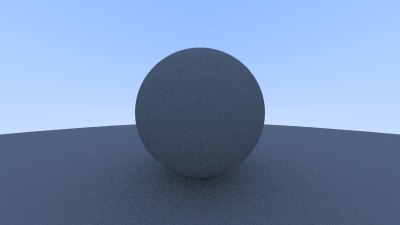

In [45]:
cam.show()